> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy numpy


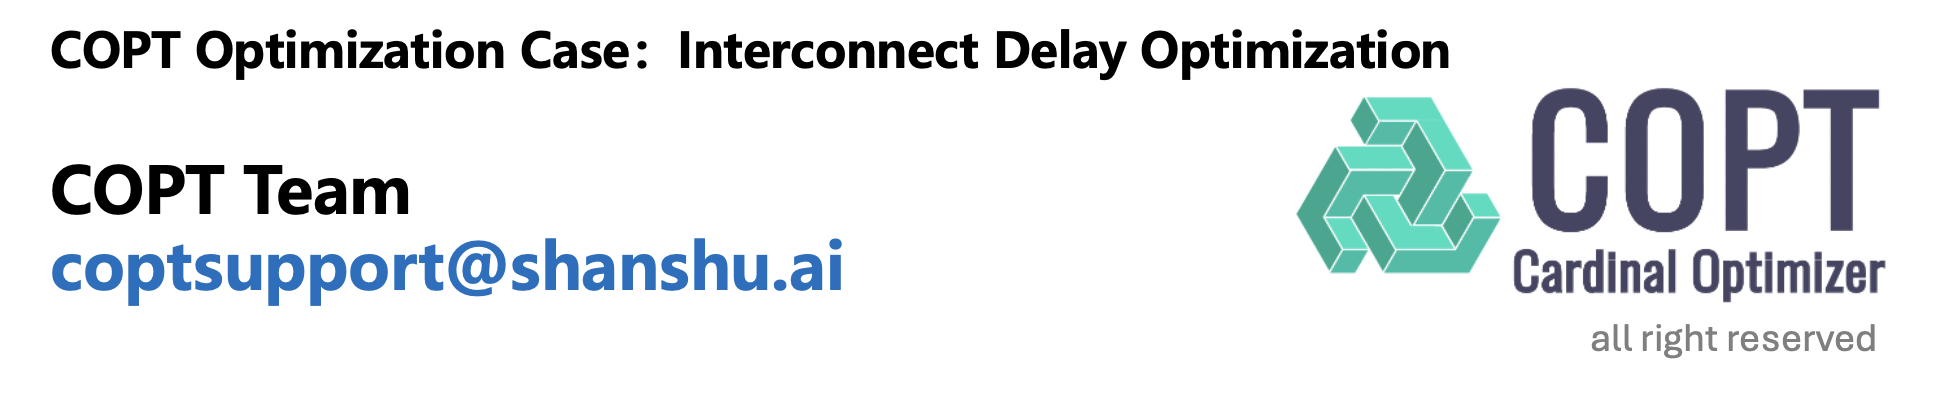

# Interconnect Delay Optimization Problem Code Implementation
## Steps to Model and Solve Interconnect Delay Optimization Problem Using COPT

1. Import the COPT-Python interface library `coptpy`

2. Add/Import model **data**

3. Create the **COPT solving environment** and the **COPT model**

4. Build the model by sequentially adding the **three essential model components**:
- Add **decision variables**: multidimensional variables can be efficiently added in batches
- Set the **objective function**: use auxiliary variables to construct three inequality constraints as a replacement for the maximum function
- Add **constraints**: nonlinear expressions can be constructed using the `nl` namespace, and `Model.addNLConstr()` can be used to add nonlinear expressions as constraints
- (Add **exponential cones**: `Model.addExpCone([x,y,z], COPT.EXPCONE_PRIMAL)` requires standard form (input variables must be single elements); `Model.addAffineCone()` can accept affine cone form input. The affine cone object is first instantiated using the `AffineConeBuilder` class to add more complex exponential cones.)

5. **Solve**

6. View and analyze **results**

<font color=#0000FF>
<b>Note: To use COPT’s affine cone and exponential cone modules, COPT version 7.2.4 or above is required.</b>
</font>


## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT
import numpy as np

## Add Model Data

In [6]:
C_load1 = 1.5
C_load2 = 1
C_load3 = 5
k0 = 1.0
rho = 1.0

## Problem 1: Solving with the Nonlinear Module
We directly solve the problem with nonconvex nonlinear constraints.


### Create the COPT Environment and COPT Model
Create a model named `interconnect_sizing_1` as `model_1`.

In [9]:
env = cp.Envr()
model_1 = env.createModel("interconnect_sizing_1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



### Add three core components of COPT Model

#### Add Decision Variables
Add decision variables $w_i$, where $w_i \in [0.1,\ 10],\ i \in W\_index$; and add decision variable $T$.


In [11]:
# Add wire numbers 1-6
W_index = list(range(1, 7))

# Add variable w1,... w6 represents the line width, with a value range of [0.1, 10].
w = model_1.addVars(W_index, lb=0.1, ub=10.0, nameprefix="w")

# Add the variable T as the maximum delay
T = model_1.addVar(name="T")

#### Set Objective Function
The objective function is
$$
\min_{w_i}\ T
$$


In [13]:
# Minimize T
model_1.setObjective(T, sense=COPT.MINIMIZE)

#### Add Constraints
Add the expressions for the three load delays $T_{load1}$, $T_{load2}$, and $T_{load3}$.
$$
C_i = k_0\ w_i
$$
$$
R_i = \frac{\rho}{w_i}
$$
$$
\begin{aligned}
T_{load1} &= (C_3+C_{load1})(R_1+R_2+R_3)+C_2(R_1+R_2)+(C_1+C_4+C_5+C_{load2}+C_6+C_{load3})R_1 \\
T_{load2} &= (C_5+C_{load2})(R_1+R_4+R_5)+(C_4+C_6+C_{load3})(R_1+R_4)+(C_1+C_2+C_3+C_{load1})R_1 \\
T_{load3} &= (C_6+C_{load3})(R_1+R_4+R_6)+(C_4+C_5+C_{load2})(R_1+R_4)+(C_1+C_2+C_3+C_{load1})R_1 \\
\end{aligned}
$$
Add three constraints ensuring the maximum load delay $T$ is no less than any single load delay $T_{load1}$, $T_{load2}$, $T_{load3}$:
$$
T \geq T_{load1}
$$
$$
T \geq T_{load2}
$$
$$
T \geq T_{load3}
$$


<font color=#0000FF>
<b>Tip: Constructing Nonlinear Constraints in the Model</b>
</font>

Currently, COPT’s native programming language modeling interface supports adding nonlinear function expressions directly in objectives and constraints.  
For example, in the COPT-Python interface, nonlinear expressions can be constructed using arithmetic operations and nonlinear functions from the `nl` namespace.  
Typical functions include:  
- `nl.pow()` for power functions  
- `nl.abs()` for absolute value  
- `nl.sin()` for sine function  
- `nl.exp()` for the natural exponential function  
- `nl.sqrt()` for square root  

To add nonlinear constraints:  
- `addNlConstr(lhs, sense=None, rhs=None, name="")`: adds a nonlinear constraint to the model.  
If `lhs` is a nonlinear expression, both `sense` (constraint direction) and `rhs` (right-hand side) must be specified.

For more details on other supported nonlinear operations and the addition of nonlinear constraints, please refer to the [COPT User Manual: Python API](https://guide.coap.online/copt/en-doc/pyapiref.html).


In [16]:
# Resistance R[i] = rho/w[i]

R = {i: rho / w[i] for i in W_index}

# Capacitance C[i] = k0 * w[i]
C = {i: k0 * w[i] for i in W_index}


# Delay expression construction
T_load1 = (C[3] + C_load1) * (R[1] + R[2] + R[3]) + \
          C[2] * (R[1] + R[2]) + \
          (C[1] + C[4] + C[5] + C_load2 + C[6] + C_load3) * R[1]

T_load2 = (C[5] + C_load2) * (R[1] + R[4] + R[5]) + \
          (C[4] + C[6] + C_load3) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

T_load3 = (C[6] + C_load3) * (R[1] + R[4] + R[6]) + \
          (C[4] + C[5] + C_load2) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

# Add nonlinear constraints: T ≥ T_load1, T ≥ T_load2, T ≥ T_load3, to achieve T = max{T_load1, T_load2, T_load3}
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load1, name="T_load1_constraint")
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load2, name="T_load2_constraint")
model_1.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load3, name="T_load3_constraint")

<coptpy.NlConstraint: T_load3_constraint>

### Solve

In [18]:
model_1.solve()

Model fingerprint: 2e7f30dd

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

The presolved problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +9.99999000e-03  +9.79000011e+00  +1.78171833e+02  +9.99996804e-01   0.00s
   1  +1.00041666e-01  +7.14084013e+00  +9.12405502e+01  +7.34709645e-01   0.00s
   2  +1.00673776e-01  +7.62011761e-01  +4.74404908e+01  +7.55688506e-01   0.00s
   3  +1.03434675e-01  +3.79288606e-01  +2.62426196e+01  +2.96701907e-01   0.01s
   4  +1.06277675e-01  +1.16179929e-01  +1.83600399e

### Retrieve Results

In [20]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
    print("Optimal T = {0:.3f}".format(T.X))
    print("Widths:")
    vars = model_1.getVars()
    for var in vars:
        if var.name.startswith("w"):
            print(" {0} = {1:.3f}".format(var.name, var.x))
else:
    print("Solve failed with status:", model_1.status)

Optimal T = 7.920
Widths:
 w(1) = 10.000
 w(2) = 2.355
 w(3) = 1.274
 w(4) = 9.421
 w(5) = 0.849
 w(6) = 4.246


## Problem 2: Solving with the Exponential Cone Module
We transform the original problem into an optimization problem with exponential cone constraints.

### Create the COPT Environment and COPT Model
Create a model named `interconnect_sizing_2` as `model_2`.


In [22]:
env = cp.Envr()
model_2 = env.createModel("interconnect_sizing_2")
model_2.matrixmodelmode = "experimental"

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



### Add three core components of COPT Model

#### Add Decision Variables
Add decision variables $y_i$, where $y_i \in [\ln 0.1,\ \ln 10],\ i \in W\_index$; and add decision variable $T$.

Add auxiliary variables for the model: $t\_{load1}$, $t\_{load2}$, $t\_{load3}$, $\{u\_{load1_i}\}^{14}_{i=1}$, $\{u\_{load2_j}\}^{16}_{j=1}$, $\{u\_{load3_k}\}^{16}_{k=1}$, and $one$.

For the variable $one$, we set both its lower and upper bounds equal to $1$ so that its value is fixed at $1$.


In [24]:
# Add wire number 1-6
W_index = list(range(1, 7))
# Add the logarithm of wire width, i.e., variables y[1] ,..., y[6], y[i] = ln(w[i])
y = model_2.addVars(W_index, lb=np.log(0.1), ub=np.log(10.0), nameprefix="y")
# Add variable T representing the maximum delay
T = model_2.addVar(name="T")

# Add auxiliary variables
t_load1 = model_2.addVar(name="t_load1")
t_load2 = model_2.addVar(name="t_load2")
t_load3 = model_2.addVar(name="t_load3")
u_load1 = model_2.addVars(14, nameprefix="u_load1", lb=0, ub=1)
u_load2 = model_2.addVars(16, nameprefix="u_load2", lb=0, ub=1)
u_load3 = model_2.addVars(16, nameprefix="u_load3", lb=0, ub=1)
one = model_2.addVar(lb=1.0, ub=1.0, name="one")

#### Set Objective Function
The objective function is
$$
\min_{\mathbf{y}}\ T
$$


In [26]:
# Minimize T
model_2.setObjective(T, sense=COPT.MINIMIZE)

#### Add Constraints
$T$ is the maximum delay of signal propagation to the three terminal loads.
$$
\begin{cases}
(T,\ 1,\ t\_{load1}) \in K_{\text{exp}} \\
\sum_{i=1}^{14} u\_{load1}_i = 1 \\
(u\_{load1}_i,\ 1,\ \mathbf{a\_{load1}_i^{\top}} \cdot \mathbf{y} + b\_{load1}_i - t\_{load1} ) \in K_{\text{exp}},\ i = 1,\ \cdots ,14
\end{cases}
$$
$$
\begin{cases}
(T,\ 1,\ t\_{load2}) \in K_{\text{exp}} \\
\sum_{j=1}^{16} u\_{load2}_j = 1 \\
(u\_{load2}_j,\ 1,\ \mathbf{a\_{load2}_j^{\top}} \cdot \mathbf{y} + b\_{load2}_j - t\_{load2} ) \in K_{\text{exp}},\ j = 1,\ \cdots ,16
\end{cases}
$$
$$
\begin{cases}
(T,\ 1,\ t\_{load3}) \in K_{\text{exp}} \\
\sum_{k=1}^{16} u\_{load3}_k = 1 \\
(u\_{load3}_k,\ 1,\ \mathbf{a\_{load3}_k^{\top}} \cdot \mathbf{y} + b\_{load3}_k - t\_{load3} ) \in K_{\text{exp}},\ k = 1,\ \cdots ,16
\end{cases}
$$


1. Add three standard exponential cone constraints.  
When constructing and adding exponential cone constraints with the COPT solver, the variables must be provided in the standard format `vars = [x_1, x_2, x_3]`, meaning each element of the cone must be a single variable (not a linear expression or constant). Therefore, the constant 1 is replaced with the auxiliary variable `one`:
$$
(T,\ one,\ t\_{load1}) \in K_{\text{exp}}
$$
$$
(T,\ one,\ t\_{load2}) \in K_{\text{exp}}
$$
$$
(T,\ one,\ t\_{load3}) \in K_{\text{exp}}
$$


In [29]:
model_2.addExpCone([T, one, t_load1], COPT.EXPCONE_PRIMAL)
model_2.addExpCone([T, one, t_load2], COPT.EXPCONE_PRIMAL)
model_2.addExpCone([T, one, t_load3], COPT.EXPCONE_PRIMAL)

<coptpy.ExpCone>

2. Add constraints requiring the sums of auxiliary variables  
$\{u\_{load1_i}\}^{14}_{i=1}$, $\{u\_{load2_j}\}^{16}_{j=1}$, and $\{u\_{load3_k}\}^{16}_{k=1}$  
to each equal 1:
$$
\sum_{i=1}^{14} u\_{load1_i} = 1
$$
$$
\sum_{j=1}^{16} u\_{load2_j} = 1
$$
$$
\sum_{k=1}^{16} u\_{load3_k} = 1
$$


In [31]:
model_2.addConstr(cp.quicksum(u_load1) == 1)
model_2.addConstr(cp.quicksum(u_load2) == 1)
model_2.addConstr(cp.quicksum(u_load3) == 1)

<coptpy.Constraint: >

3. Add the exponents of each term and the logarithms of the coefficients in the expressions $T_{load1}$, $T_{load2}$, and $T_{load3}$ to construct affine cone constraints.
Below are the expanded delay expressions and their corresponding $log\text{-}sum\text{-}exp$ forms:
$$
\begin{aligned}
T_{load1} =\ & k_0 \rho w_1^{-1} w_3 + k_0 \rho w_2^{-1} w_3 + k_0 \rho + \rho C_{load1} w_1^{-1} + \rho C_{load1} w_2^{-1} + \rho C_{load1} w_3^{-1} + \\
 & k_0 \rho w_1^{-1} w_2 + k_0 \rho \ + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_4 + k_0 \rho w_1^{-1} w_5 + \rho C_{load2} w_1^{-1} + k_0 \rho w_1^{-1} w_6 + \rho C_{load3} w_1^{-1} \\
T_{load1} =\ & \sum_{i=1}^{14} e^{\mathbf{a\_load1_i^{\top}} \cdot \mathbf{y} + b\_load1_i} \\
\end{aligned}
$$
$$
\begin{aligned}
T_{load2} =\ & k_0 \rho w_1^{-1} w_5 + k_0 \rho w_4^{-1} w_5 + k_0 \rho + \rho C_{load2} w_1^{-1} + \rho C_{load2} w_4^{-1} + \rho C_{load2} w_5^{-1} + \\
 & k_0 \rho w_1^{-1} w_4 + k_0 \rho \ + k_0 \rho w_1^{-1} w_6 + k_0 \rho w_4^{-1} w_6 + \rho C_{load3} w_1^{-1} + \rho C_{load3} w_4^{-1} + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_2 + k_0 \rho w_1^{-1} w_3 + \rho C_{load1} w_1^{-1} \\
T_{load2} =\ & \sum_{j=1}^{16} e^{\mathbf{a\_load2_j^{\top}} \cdot \mathbf{y} + b\_load2_j} \\
\end{aligned}
$$
$$
\begin{aligned}
T_{load3} =\ & k_0 \rho w_1^{-1} w_6 + k_0 \rho w_4^{-1} w_6 + k_0 \rho + \rho C_{load3} w_1^{-1} + \rho C_{load3} w_4^{-1} + \rho C_{load3} w_6^{-1} + \\
 & k_0 \rho w_1^{-1} w_4 + k_0 \rho \ + k_0 \rho w_1^{-1} w_5 + k_0 \rho w_4^{-1} w_5 + \rho C_{load2} w_1^{-1} + \rho C_{load2} w_4^{-1} + \\
 & k_0 \rho + k_0 \rho w_1^{-1} w_2 + k_0 \rho w_1^{-1} w_3 + \rho C_{load1} w_1^{-1} \\
T_{load3} =\ & \sum_{k=1}^{16} e^{\mathbf{a\_load3_k^{\top}} \cdot \mathbf{y} + b\_load3_k} \\
\end{aligned}
$$


In [33]:
A_load1 = [[-1, 0, 1, 0, 0, 0],
           [0, -1, 1, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, -1, 0, 0, 0, 0],
           [0, 0, -1, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 1, 0, 0],
           [-1, 0, 0, 0, 1, 0],
           [-1, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 1],
           [-1, 0, 0, 0, 0, 0]]
B_load1 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load1*rho, C_load1*rho, C_load1*rho,
                           k0*rho, k0*rho,
                           k0*rho, k0*rho, k0*rho, C_load2*rho, k0*rho, C_load3*rho]))
A_load2 = [[-1, 0, 0, 0, 1, 0],
           [0, 0, 0, -1, 1, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, -1, 0],
           [-1, 0, 0, 1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 1],
           [0, 0, 0, -1, 0, 1],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [-1, 0, 1, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0]]
B_load2 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load2*rho, C_load2*rho, C_load2*rho,
                           k0*rho, k0*rho, k0*rho, k0*rho, C_load3*rho, C_load3*rho,
                           k0*rho, k0*rho, k0*rho, C_load1*rho]))
A_load3 = [[-1, 0, 0, 0, 0, 1],
           [0, 0, 0, -1, 0, 1],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, -1],
           [-1, 0, 0, 1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 0, 0, 0, 1, 0],
           [0, 0, 0, -1, 1, 0],
           [-1, 0, 0, 0, 0, 0],
           [0, 0, 0, -1, 0, 0],
           [0, 0, 0, 0, 0, 0],
           [-1, 1, 0, 0, 0, 0],
           [-1, 0, 1, 0, 0, 0],
           [-1, 0, 0, 0, 0, 0]]
B_load3 = np.log(np.array([k0*rho, k0*rho, k0*rho, C_load3*rho, C_load3*rho, C_load3*rho,
                           k0*rho, k0*rho, k0*rho, k0*rho, C_load2*rho, C_load2*rho,
                           k0*rho, k0*rho, k0*rho, C_load1*rho]))

We aim to add the original affine-form exponential cone constraints:
$$
(u\_{load1}_i,\ 1,\ \mathbf{a\_{load1}_i^{\top}} \cdot \mathbf{y} + b\_{load1}_i - t\_{load1} ) \in K_{\text{exp}},\ i = 1,\ \cdots ,14
$$
$$
(u\_{load2}_j,\ 1,\ \mathbf{a\_{load2}_j^{\top}} \cdot \mathbf{y} + b\_{load2}_j - t\_{load2} ) \in K_{\text{exp}},\ j = 1,\ \cdots ,16
$$
$$
(u\_{load3}_k,\ 1,\ \mathbf{a\_{load3}_k^{\top}} \cdot \mathbf{y} + b\_{load3}_k - t\_{load3} ) \in K_{\text{exp}},\ k = 1,\ \cdots ,16
$$
Since COPT 7.2.4, COPT has added support for **affine cone modeling** , making it easier to model complex cone constraints. The elements forming the cone can be linear expressions or constants, eliminating the need to introduce auxiliary variables for standard-form conversion. Therefore, here we demonstrate directly adding exponential cone constraints in affine form. This effectively controls the problem size and is modeling-friendly, closely matching the algebraic form above.

In [35]:
for i in range(14):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load1[i])
    afcone_1 = cp.AffineConeBuilder()
    afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u_load1[i], 1, expr + B_load1[i] - t_load1])
    model_2.addAffineCone(afcone_1)
for j in range(16):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load2[j])
    afcone_2 = cp.AffineConeBuilder()
    afcone_2.setBuilder(COPT.EXPCONE_PRIMAL, [u_load2[j], 1, expr + B_load2[j] - t_load2])
    model_2.addAffineCone(afcone_2)
for k in range(16):
    expr = cp.LinExpr()
    expr.addTerms(y.values(), A_load3[k])
    afcone_3 = cp.AffineConeBuilder()
    afcone_3.setBuilder(COPT.EXPCONE_PRIMAL, [u_load3[k], 1, expr + B_load3[k] - t_load3])
    model_2.addAffineCone(afcone_3)

### Solve

In [37]:
model_2.solve()

Model fingerprint: 682ee232

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    3 rows, 57 columns and 46 non-zero elements
    3 exponential cones
    46 affine cones
The presolved problem has:
    51 rows, 153 columns and 199 non-zero elements
    49 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [4e-01,2e+00]
    Range of bound coefficients:     [1e+00,2e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        7.350e+02
    Number of factor entries:        9.630e+02
    Number of factor flops:          2.334e+04

Iter       Primal.Obj         Dual.Obj      Co

### Retrieve Results

Note that the solved $y_i$ are actually the logarithms of the wire widths. You need to apply $w_i = e^{y_i}$ to obtain the wire widths $w_i$.


In [40]:
if model_2.status == COPT.OPTIMAL:
    print("Optimal T = {0:.3f}".format(T.X))
    print("Widths:")
    vars = model_2.getVars()
    for var in vars:
        if var.name.startswith("y"):
            print(" {0} = {1:.3f}".format("w"+var.name[1:4], np.exp(var.x)))
else:
    print("Solve failed with status:", model_2.status)

Optimal T = 7.920
Widths:
 w(1) = 10.000
 w(2) = 2.355
 w(3) = 1.274
 w(4) = 9.421
 w(5) = 0.849
 w(6) = 4.246


## Case Expansion: Multi-Objective Optimization for Signal Delay and Wire Area 

In addition to the maximum signal delay $T$ of the terminal loads in the original problem, we now also consider the total wire area $A$.  
Since the two optimization objectives have equal priority, we use the weighted-sum method for modeling and solving.

Create a model named `interconnect_sizing_3` as `model_3`, and configure the decision variables and constraints in the same way as in `model_1`.


In [42]:
env = cp.Envr()
model_3 = env.createModel("interconnect_sizing_3")

# Add wire number 1-6
W_index = list(range(1, 7))

# Add variable w1 ,..., w6 representing wire width, with range [0.1, 10]
w = model_3.addVars(W_index, lb=0.1, ub=10.0, nameprefix="w")

# Add variable T representing the maximum delay
T = model_3.addVar(name="T")

# Resistance R[i] = rho / w[i]
R = {i: rho /w[i]  for i in W_index}

# Capacitance C[i] = k0 * w[i]
C = {i: k0 * w[i] for i in W_index}


# Delay expression construction
T_load1 = (C[3] + C_load1) * (R[1] + R[2] + R[3]) + \
          C[2] * (R[1] + R[2]) + \
          (C[1] + C[4] + C[5] + C_load2 + C[6] + C_load3) * R[1]

T_load2 = (C[5] + C_load2) * (R[1] + R[4] + R[5]) + \
          (C[4] + C[6] + C_load3) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]

T_load3 = (C[6] + C_load3) * (R[1] + R[4] + R[6]) + \
          (C[4] + C[5] + C_load2) * (R[1] + R[4]) + \
          (C[1] + C[2] + C[3] + C_load1) * R[1]


# Add nonlinear constraints: T ≥ T1, T ≥ T2, T ≥ T3, to achieve T = max{T1, T2, T3}
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load1, name="T_load1_constraint")
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load2, name="T_load2_constraint")
model_3.addNlConstr(lhs=T, sense=COPT.GREATER_EQUAL, rhs=T_load3, name="T_load3_constraint")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



<coptpy.NlConstraint: T_load3_constraint>

**Add Objective Function**

Set the objective function as a weighted combination of the maximum signal delay $T$ at the terminal loads and the total wire area $A$:
$$
\min_{w_i} \lambda_{T} T + \lambda_{A} A
$$
where $A = \sum_{i} w_i$. $\lambda_{T}$ and $\lambda_{A}$ are the weight coefficients of the two optimization objectives, representing their relative importance in the composite objective. Here we assume $\lambda_{T} = 0.7$ and $\lambda_{A} = 0.3$.


In [44]:
A = cp.quicksum(w)
lambda_T = 0.7
lambda_A = 0.3

For multi-objective optimization problems like ours, where the objective function is relatively simple and the number of optimization goals is small, we can directly write the weighted sum expression (weight $\times$ objective) into the objective function.


In [46]:
# Write the weighted sum expression (weight * objective) into the objective function directly
# model_3.setObjective(lambda_T*T + lambda_A*A, sense=COPT.MINIMIZE)

However, in practice, when solving multi-objective optimization problems, the expressions may be more complex, involve more objectives, and require priority distinctions. In such cases, it is recommended to use the more standardized `Model.setObjectiveN()` approach.

<font color=#0000FF>
<b>Tip: Using COPT's Multi-Objective Modeling Functionality</b>
</font>

COPT supports linear objectives in multi-objective optimization, which can be set using the API method `Model.setObjectiveN()`.

- `Model.setObjectiveN(idx, expr, sense=None, priority=0.0, weight=1.0, abstol=1e-6, reltol=0.0)`:  
  Sets the objective function with a specified index in multi-objective optimization.  
  - `idx`: The index of the objective function (integer).  
  - `expr`: The expression of the objective function (linear expression).  
  - `sense`: The optimization direction of the objective function (optional, default `None`).  
  - `priority`: The priority level of the objective function (optional, default `0.0`).  
  - `weight`: The weight of the objective function (optional, default `1.0`).  
  - `abstol`: The absolute deviation tolerance of the objective function (optional, default `1e-6`).  
  - `reltol`: The relative deviation tolerance of the objective function (optional, default `0.0`).  

For details on other parameter settings and input types, please refer to [COPT User Manual: Python API](https://guide.coap.online/copt/en-doc/pyapiref.html).


In [48]:
model_3.setObjectiveN(idx=0, expr=T, sense=COPT.MINIMIZE, weight=lambda_T)
model_3.setObjectiveN(idx=1, expr=A, sense=COPT.MINIMIZE, weight=lambda_A)

In [49]:
model_3.solve()

Model fingerprint: ed0b6073

Start the multi-objective optimization with 2 objectives

Using weighted sum method

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

The presolved problem has:
    0 rows, 7 columns and 0 non-zero elements
    3 nonlinear expression constraints

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +2.04999975e-01  +9.79000011e+00  +1.78171833e+02  +1.00139218e+00   0.00s
   1  +4.61750636e-01  +7.19953905e+00  +9.12279937e+01  +7.43658728e-01   0.01s
   2  +7.80818981e-01  +5.55670977e-01  +4.74567933e+01  +6.97030250e-01   0.01s
   3  +1.65344721e+00  +3.11855031e-01  +2.72069

### Retrieve Results

By solving the above multi-objective optimization problem, we can obtain the optimal maximum signal delay at the terminals and the optimal total wire area, as well as print the optimal width of each wire.

In [51]:
if model_3.status == COPT.OPTIMAL:
    widths = [var.x for var in model_3.getVars() if var.name.startswith("w")]
    print("Optimal T = {0:.3f}".format(T.X))
    print("Optimal A = {0:.3f}".format(sum(widths)))
    print("Widths:")
    for i, item in enumerate(widths):
        print(" w({0}) = {1:.3f}".format(i+1, item))
else:
    print("Solve failed with status:", model_3.status)

Optimal T = 10.523
Optimal A = 13.025
Widths:
 w(1) = 5.851
 w(2) = 0.837
 w(3) = 0.598
 w(4) = 3.347
 w(5) = 0.399
 w(6) = 1.994
